# ตัวอย่างการใช้งาน conv+max pooling โดยใช้ข้อมูลของ Fashion MNIST
จัดทำโดย อ.ดร.ภูริวัจน์ วรวิชัยพัฒน์

In [2]:
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import numpy as np
import cv2
print(tf.config.list_physical_devices())

fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype(np.float32) / 255
test_images = test_images.astype(np.float32) / 255

# # reshape ข้อมูลเพื่อให้ใส่ CNN ได้
# train_images = train_images.reshape(60000, 28, 28, 1)
# test_images = test_images.reshape(10000, 28, 28, 1)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## แกล้งโมเดล

อย่างไรก็ตามขนาด 28*28 ก็เป็นขนาดเดิมๆที่เราใช้กันอยู่กับปกติ ซึ่งจะทำให้ไม่เห็นประสิทธิภาพของ Max Pooling อย่างชัดเจน
งั้นมาจำลองกันว่าภาพที่ได้มานั้นมีขนาดที่ไม่เท่ากันอยู่ด้วย
- เราจะทำการ zoom out ให้ภาพมีขนาดเหลือ 14x14
- จากนั้นทำการ padding (เติมขอบ) ให้กลับไปเป็น 28x28 เท่าเดิม
- เพื่อจำลองว่าข้อมูลนั้นมีวัตถุหลายระยะ

In [3]:
def zoom_out_batch(images, target_size):
    zoomed = []
    for img in images:
        small = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        pad_total = 28 - target_size
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        padded = np.pad(small, ((pad_left, pad_right), (pad_left, pad_right)), mode='constant')
        zoomed.append(padded)
    return np.array(zoomed)

In [4]:
target_size = 14

# Apply zoom to half the images
mask = np.random.rand(len(train_images)) < 0.5
print(mask) # เป็น true, false ไปครึ่งนึง
train_images_zoomed = train_images.copy()
train_images_zoomed[mask] = zoom_out_batch(train_images[mask],target_size)

mask_test = np.random.rand(len(test_images)) < 0.5
test_images_zoomed = test_images.copy()
test_images_zoomed[mask_test] = zoom_out_batch(test_images[mask_test], target_size)

[ True False  True ... False  True False]


In [5]:
def loop_plots(nrows, ncols, imgs):
    plt.figure(figsize=(10, 5), dpi=80)
    for i in range(nrows*ncols):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(imgs[i], cmap=plt.cm.gray_r)

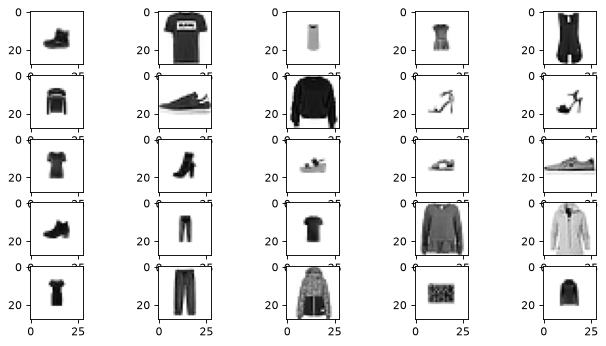

In [7]:
loop_plots(5,5, train_images_zoomed) # train

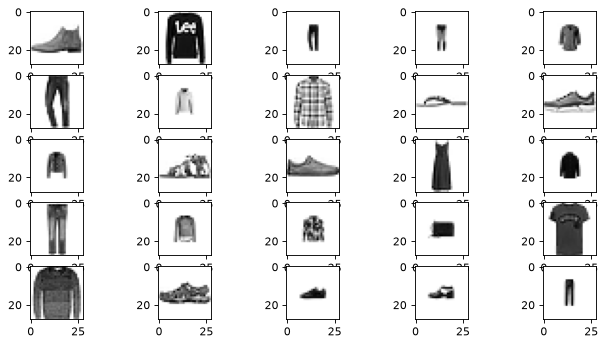

In [8]:
loop_plots(5,5, test_images_zoomed) # test

In [9]:
def plot_history(history):
    """
    Plots the training and validation accuracy and loss from the training history.
    
    Args:
    - history: A History object. The history object is returned by the `fit` method of a Keras model.
    """
    # Plot accuracy history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot loss history
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

## CNN แบบไม่มี Max pooling

- ด้านล่างจะเป็นโค้ดของ CNN 1 ชั้น ธรรมดาที่ยังไม่มีการใช้งานของ max pooling มีการใช้ dropout นิดหน่อย
- เราจะมาลองดูกันว่าถ้า CNN เจอกับข้อมูลที่มีวัตถุหลายระยะแล้วจะเป็นอย่างไร
- ตอนนี้ข้อมูลฝึกจะเป็น `train_images_zoomed` และข้อมูล val จะเป็น `test_images_zoomed` ใน `fit()`
```python
fit(**train_images_zoomed**, train_labels, epochs=20, batch_size=128,
    validation_data=(**test_images_zoomed**, test_labels))

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,210 (981.29 KB)

 Trainable params: 251,210 (981.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7910 - loss: 0.6141 - val_accuracy: 0.8232 - val_loss: 0.5028
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8518 - loss: 0.4255 - val_accuracy: 0.8512 - val_loss: 0.4339
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8681 - loss: 0.3777 - val_accuracy: 0.8612 - val_loss: 0.4047
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8770 - loss: 0.3491 - val_accuracy: 0.8585 - val_loss: 0.3907
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8838 - loss: 0.3284 - val_accuracy: 0.8651 - val_loss: 0.3849
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8898 - loss: 0.3138 - val_accuracy: 0.8672 - val_loss: 0.3790
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8929 - loss: 0.3007 - val_accuracy: 0.8737 - val_loss: 0.3709
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8956 - loss: 0.2919 - v

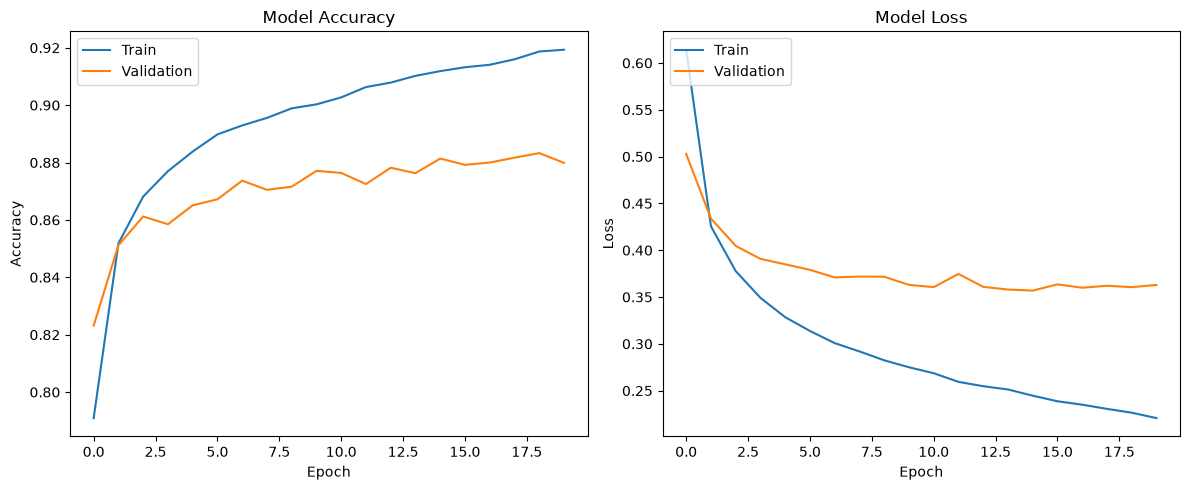

In [9]:
# Define CNN model without MaxPooling
model_no_pool = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu, padding='same', 
                        input_shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model_no_pool.summary()
# Compile both models
model_no_pool.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_no_pool = model_no_pool.fit(train_images_zoomed, train_labels, epochs=20, batch_size=128,
                                    validation_data=(test_images_zoomed, test_labels))
plot_history(history_no_pool)

## CNN แบบมี Max Pooling

โค้ดด้านล่างจะเป็นการประกาศ max pooling ด้วย
> `keras.layers.MaxPooling2D((2,2)),`

การใส่พารามิเตอร์แบบนี้เป็นการบอกว่าใช้ filter ขนาด 2x2
พารามิเตอร์ที่สามารถกำหนดได้อีกตัวคือ stride ที่จะบอกว่าขยับ filter ทีละกี่ pixel ถ้าไม่ใส่ <font color="blue"> stride จะมีค่าเป็น (2, 2) โดด w, h ทีละ 2, 2</font>

- โดยปกติแล้ว max pool จะใส่หลังจากทำ conv2d เพื่อดึง feature ที่เด่นๆออกมาก่อนจะส่งไปเลเยอร์ถัดไป <br>
- ตัวโมเดลด้านล่างเป็นการใช้ max pooling ทั้งหมด 1 ครั้ง
- มาดูกันว่าเมื่อเราใส่ maxpooling เข้าไปแล้วผลลัพธ์จะออกมาดีกว่าโมเดลก่อนหน้าหรือไม่?

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        62,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,050 (246.29 KB)

 Trainable params: 63,050 (246.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7603 - loss: 0.7138 - val_accuracy: 0.8195 - val_loss: 0.5183
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8343 - loss: 0.4736 - val_accuracy: 0.8432 - val_loss: 0.4517
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8504 - loss: 0.4284 - val_accuracy: 0.8502 - val_loss: 0.4355
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8599 - loss: 0.4033 - val_accuracy: 0.8552 - val_loss: 0.4193
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8649 - loss: 0.3848 - val_accuracy: 0.8650 - val_loss: 0.3997
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8676 - loss: 0.3740 - val_accuracy: 0.8609 - val_loss: 0.3942
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8720 - loss: 0.3637 - val_accuracy: 0.8704 - val_loss: 0.3795
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8751 - loss: 0.3552 - val_accu

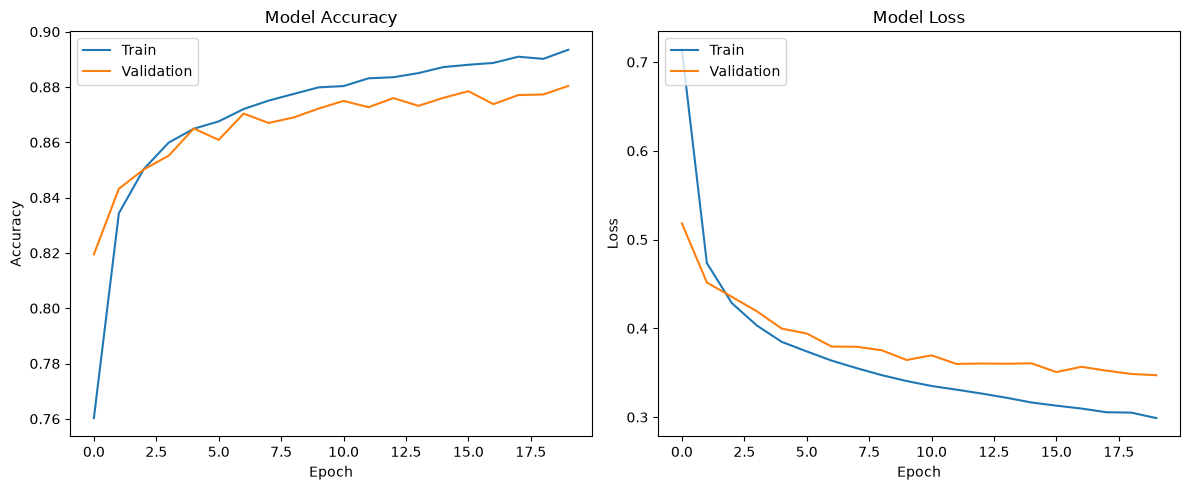

In [10]:
# CNN model ที่มี MaxPooling 1 ชั้น
model_with_pool = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28,28,1)), 
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_with_pool.summary()

model_with_pool.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
history_with_pool = model_with_pool.fit(train_images_zoomed, train_labels, batch_size=128, 
                                        epochs=20, validation_data=(test_images_zoomed, test_labels))

plot_history(history_with_pool)

## เปรียบเทียบ prediction

มาลองเปรียบเทียบว่าหลังจากมี max pool แล้วโมเดลมีความสามารถดีขึ้นไหมอย่างไร?

In [11]:
p1 = model_no_pool.predict(test_images_zoomed).astype(np.float32)
p2 = model_with_pool.predict(test_images_zoomed).astype(np.float32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
# Function ใช้ plot ค่าความน่าจะเป็นของแต่ละคลาสเทียบกัน
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel(
        "{} {:2.0f}% (true: {})".format(
            class_names[predicted_label],
            100 * np.max(predictions_array),
            class_names[true_label],
        ),
        color=color,
    )
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777") # plot bar
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color("red")
    thisplot[true_label].set_color("blue")

**ลองสังเกตุดูว่าผลลัพธ์การทำนายมีภาพไหนบ้างที่ ทำนายได้ดีขึ้นเมื่อเทียบระหว่าง 2 โมเดล??**

In [15]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

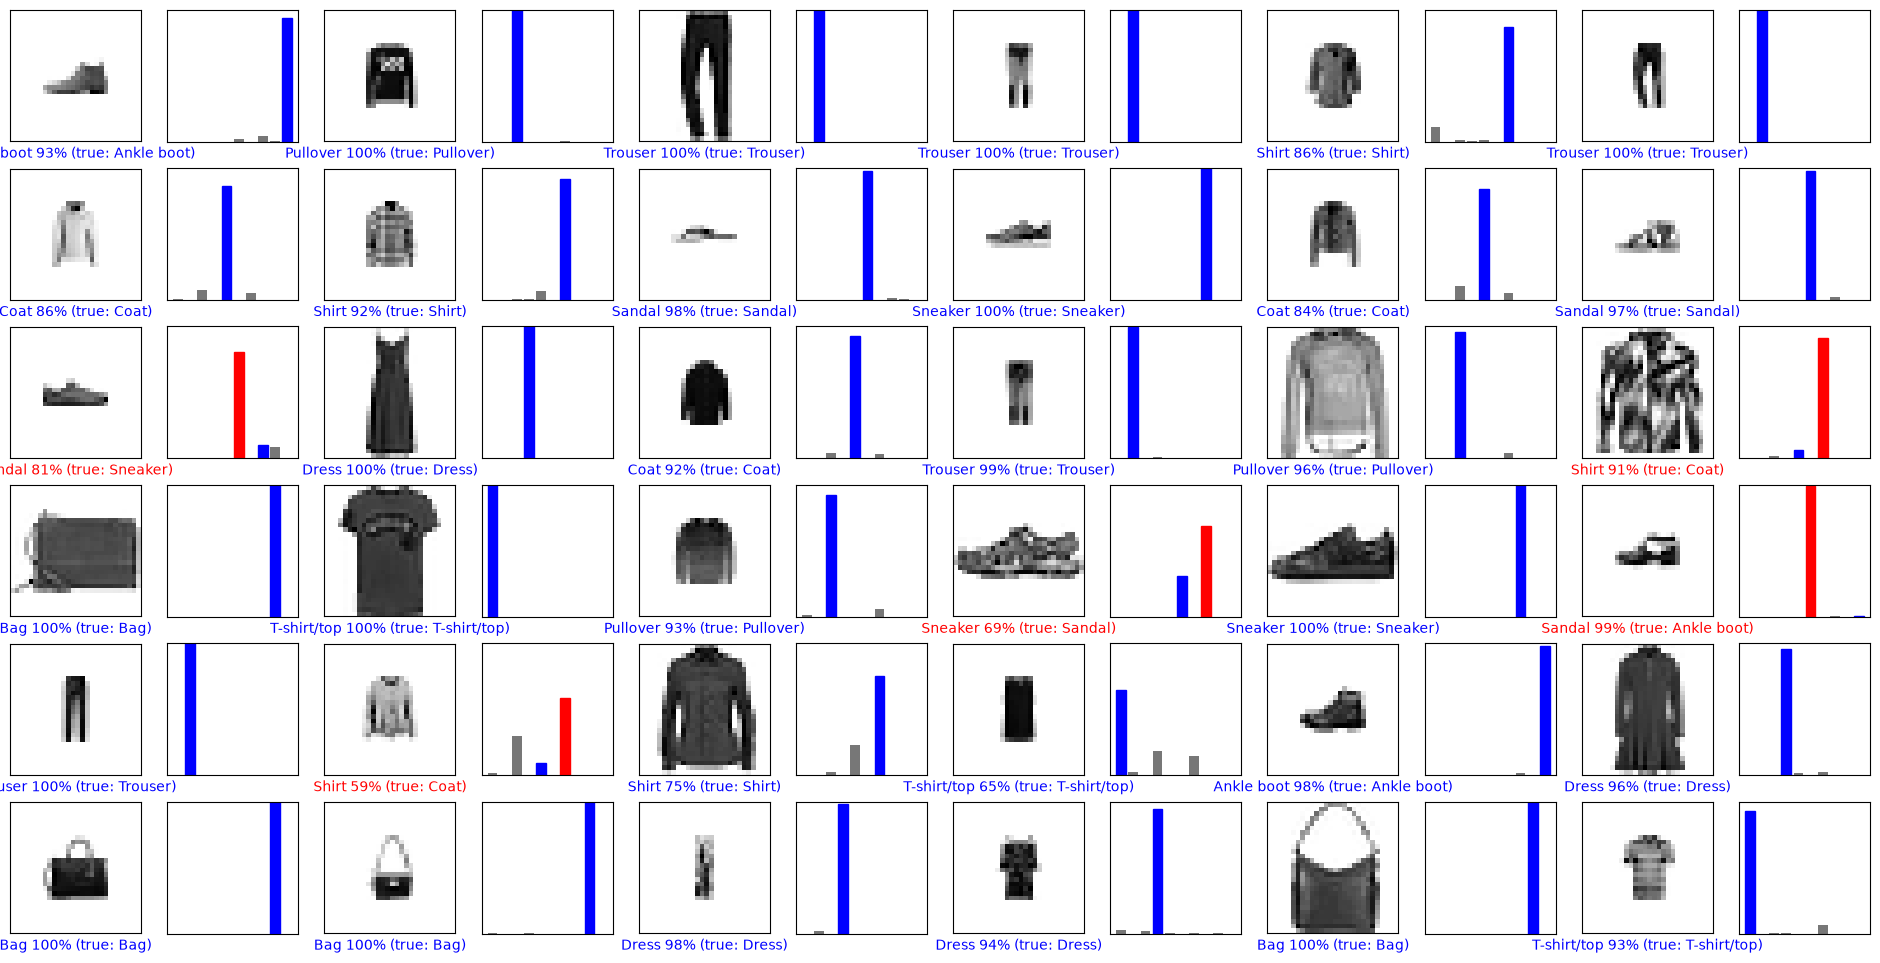

In [18]:
num_rows = 6
num_cols = 6
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, p1, test_labels, test_images_zoomed) # ใช้ p1
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, p1, test_labels)# ใช้ p1

plt.savefig("without_max_pooling.png")

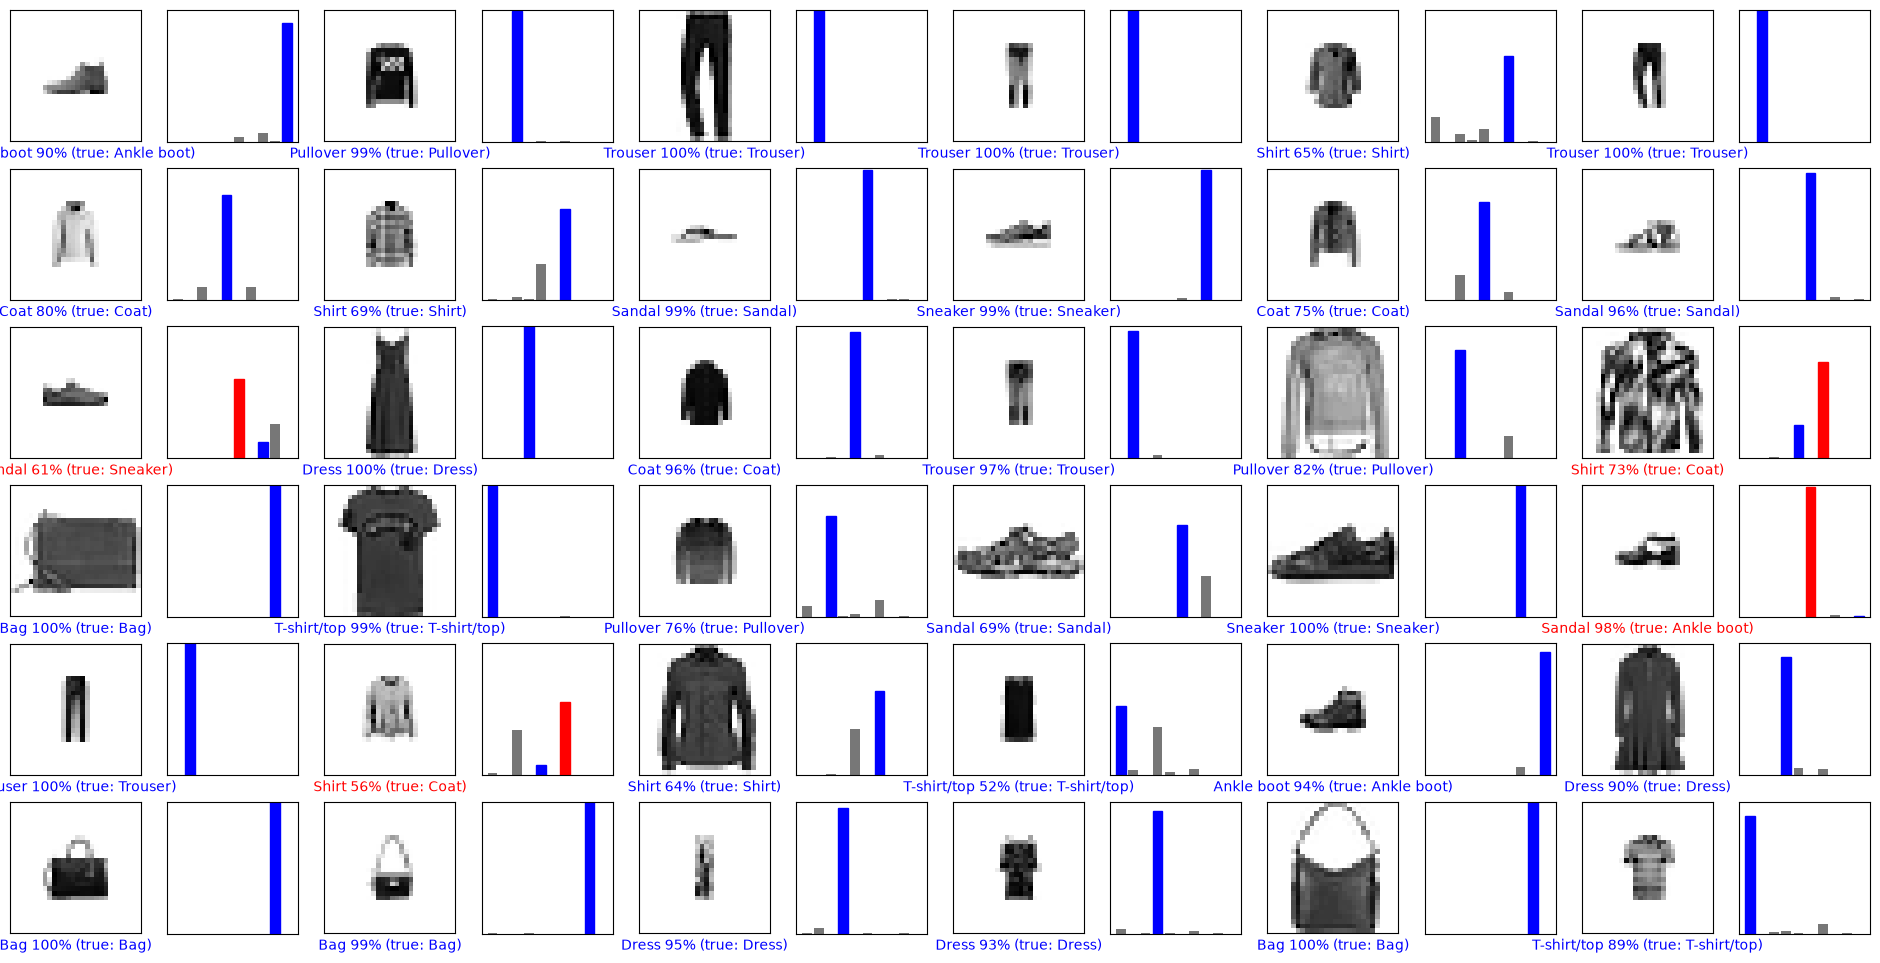

In [19]:
num_rows = 6
num_cols = 6
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, p2, test_labels, test_images_zoomed) # ใช้ p2
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, p2, test_labels)# ใช้ p2

plt.savefig("with_max_pooling.png")

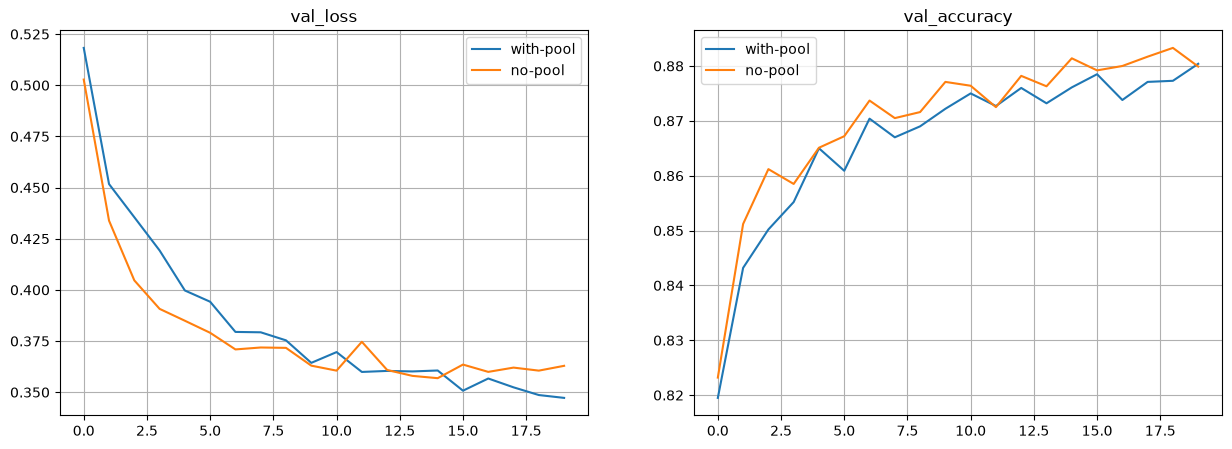

In [37]:
#comparing the model with no_pooling and with pooling
plt.figure(figsize = (15, 5))

plt.subplot(1, 2, 1)
plt.plot(history_with_pool.history['val_loss'])
plt.plot(history_no_pool.history['val_loss'])
plt.legend(['with-pool', 'no-pool'])
plt.title('val_loss')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_with_pool.history['val_accuracy'])
plt.plot(history_no_pool.history['val_accuracy'])
plt.legend(['with-pool', 'no-pool'])
plt.title('val_accuracy')
plt.grid()

## MaxPool more than 1 time

ตัวโมเดลด้านล่างเป็นการใช้ max pooling ทั้งหมด 2 ครั้งเท่านั้น
- เลเยอร์ conv2d หลังจากการทำ max pool จะมีจน. filter เพิ่มขึ้นเป็น 2 เท่า
- เพราะว่า ต่อให้ขนาดของ feature map ลดลง ปริมาณข้อมูลควรที่จะต้องเท่าเดิม จึงต้องเพิ่มจน. filter มาชดเชยในส่วนนั้น
> │ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 
- output shape นั้นขนาดเหลือเพียงแค่ 7x7 เอง หลังจากทำ maxpool ครั้งที่ 2
- หากทำ conv+maxpool ทั้งหมด 3 ครั้ง จน. filter ก็จะขึ้นไปถึง 128 ใน conv สุดท้าย
- <font color="blue">**แต่!!!! ทำ max pool มากไปก็ใช่ว่าจะดีนะ**</font>

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,186 (196.04 KB)

 Trainable params: 50,186 (196.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7376 - loss: 0.7388 - val_accuracy: 0.8114 - val_loss: 0.5289
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8263 - loss: 0.4941 - val_accuracy: 0.8421 - val_loss: 0.4600
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.8467 - loss: 0.4357 - val_accuracy: 0.8539 - val_loss: 0.4187
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8587 - loss: 0.4033 - val_accuracy: 0.8662 - val_loss: 0.3898
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8660 - loss: 0.3790 - val_accuracy: 0.8704 - val_loss: 0.3731
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8740 - loss: 0.3566 - val_accuracy: 0.8725 - val_loss: 0.3634
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8781 - loss: 0.3425 - val_accuracy: 0.8737 - val_loss: 0.3502
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8822 - loss: 0.3282 - 

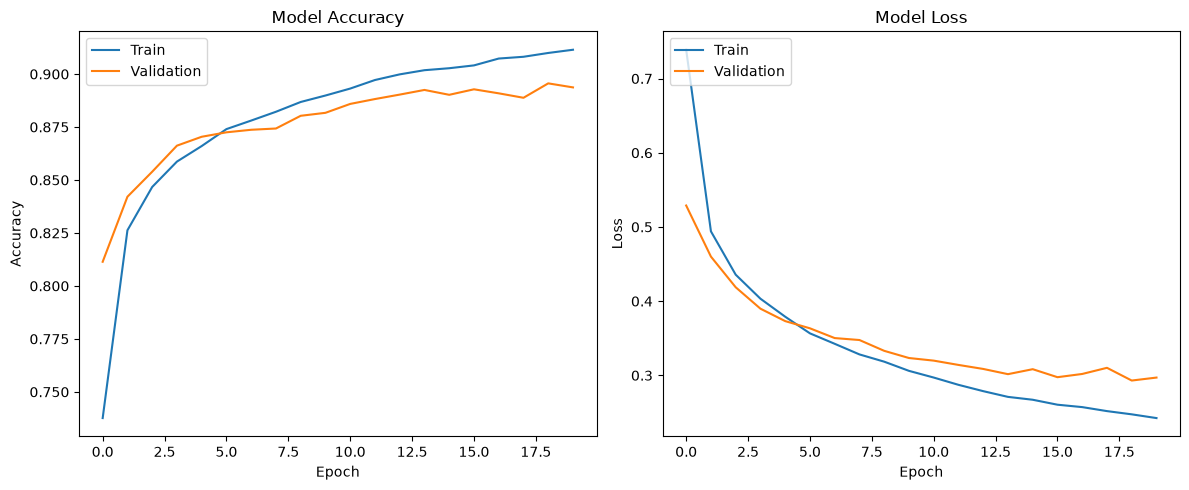

In [38]:
# CNN model ที่มี MaxPooling 2 ชั้น
model_with_2pool = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28,28,1)), 
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    # keras.layers.Dense(32, activation='relu'), # (ถ้าอยากลอง fine-tune โมเดล)
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_with_2pool.summary()

model_with_2pool.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
history_with_2pool = model_with_2pool.fit(train_images_zoomed, train_labels, batch_size=128, 
                                        epochs=20, validation_data=(test_images_zoomed, test_labels))

plot_history(history_with_2pool)

ทีนี้มาลอง predict ด้วยโมเดลที่มี max pool 2 ชั้นกันดูบ้างว่าผลลัพะ์จะดีขึ้นไหม?

In [39]:
p3 = model_with_2pool.predict(test_images_zoomed).astype(np.float32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


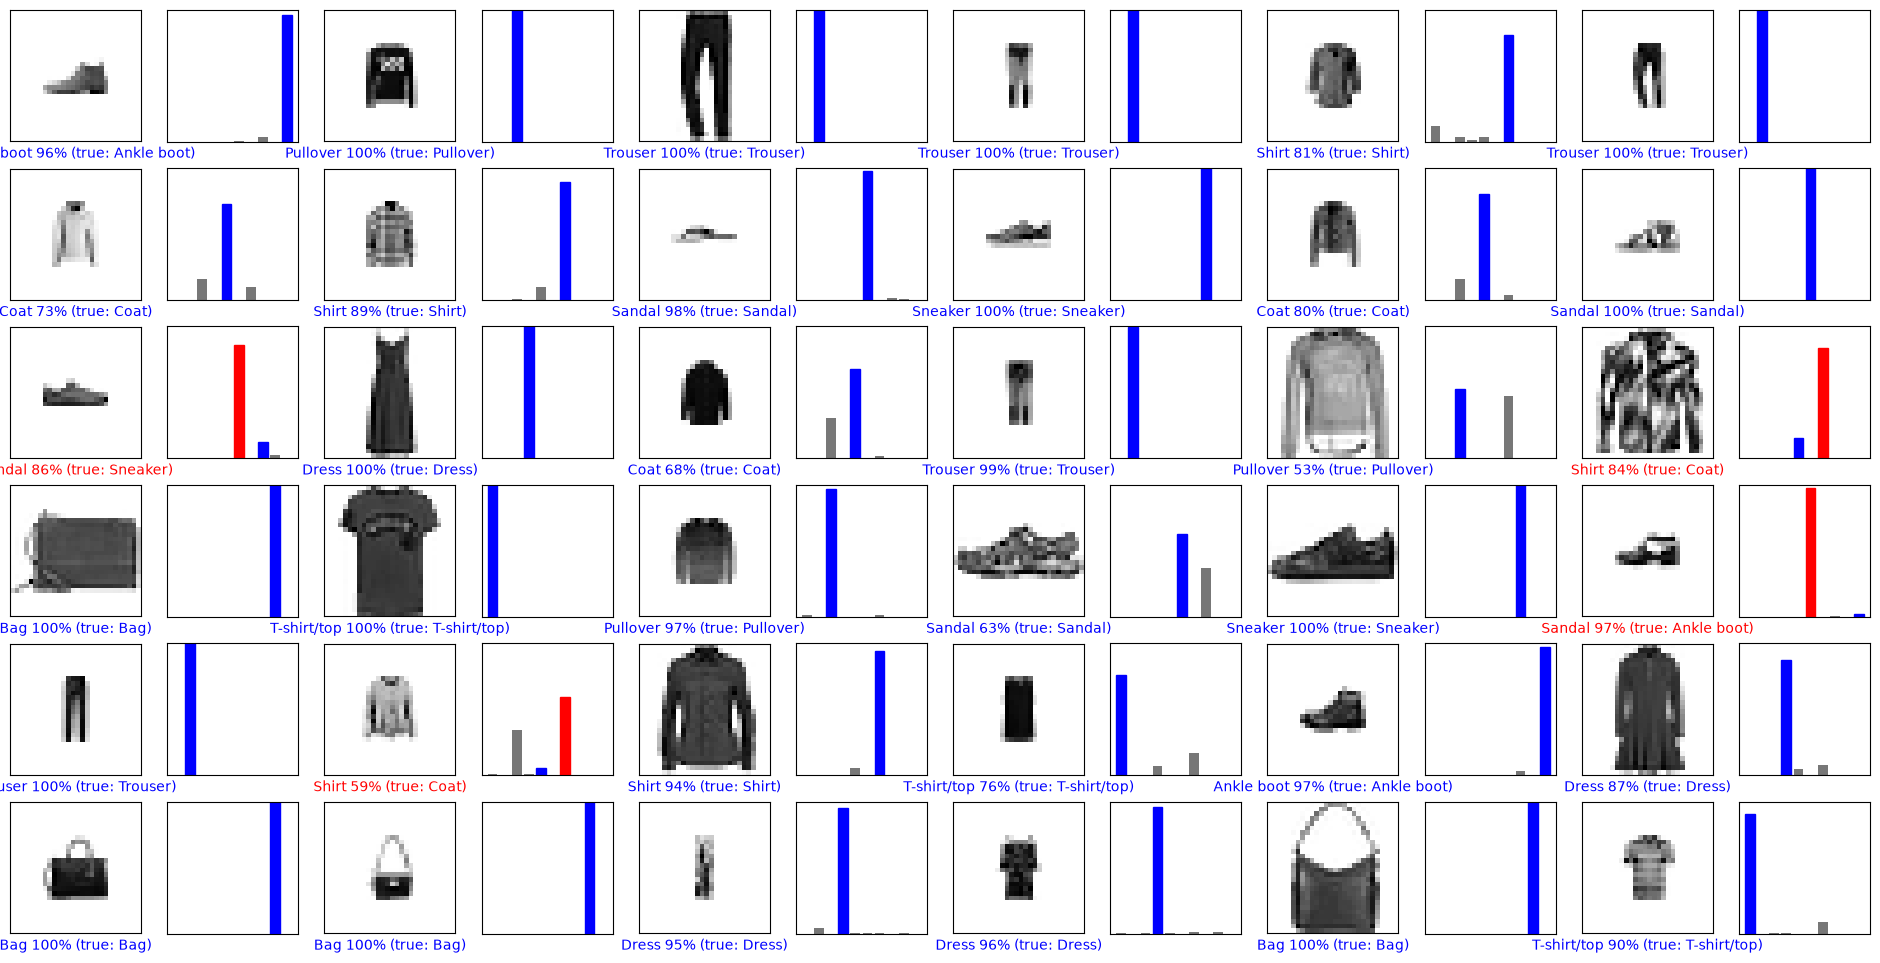

In [40]:
num_rows = 6
num_cols = 6
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, p3, test_labels, test_images_zoomed) # ใช้ p3
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, p3, test_labels) # ใช้ p3

จากการดู prediction ของ 3 โมเดลแล้วมันดีขึ้นขนาดนั้นไหม?? หรือว่าจริงๆแล้วเราดูแค่นี้อาจจะไม่ค่อยเห็นภาพ มาลองดูการวัดค่าแบบอื่นไหม

## เปรียบเทียบ loss มี/ไม่มี max pooling

- ตอนนี้มาดูแค่ความแตกต่างของ loss ระหว่างมีกับไม่มี max pooling (ลองรันโค้ดด้านล่างดู)
- จะเห็นได้ชัดว่าหลังจากใส่ max pooling เข้าไปในโมเดลแล้วประสิทธิภาพของโมเดลที่มี max pool นั้นดีกว่า
- แสดงว่าโมเดลของเรานั้นมีประสิทธิภาพในการทายคลาส แม้วัตถุมีระยะที่ไกลออกไปได้

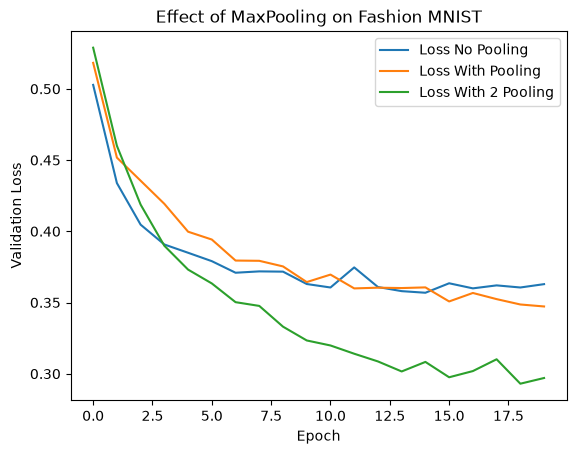

In [41]:
# Plot accuracy comparison
plt.plot(history_no_pool.history['val_loss'], label='Loss No Pooling')
plt.plot(history_with_pool.history['val_loss'], label='Loss With Pooling')
plt.plot(history_with_2pool.history['val_loss'], label='Loss With 2 Pooling')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Effect of MaxPooling on Fashion MNIST')
plt.show()

## <font color="red">แบบฝึกหัดที่ 1 ขนาดของ feature map</font>

เนื่องจากเราได้ลองใช้ max pooling ไปแล้ว ซึ่งตามทฤษฏีขนาดของ feature map ต้องมีการเปลี่ยนแปลงอย่างแน่นอน อยากให้นศ.ลองดู `summary()` หน่อยว่าเป็นเช่นนั้นหรือเปล่า
1. ในโมเดลที่ไม่มี max pooling ค่า output shape หลังจาก conv2d ครั้งที่ 1 นั้นเป็นเท่าไหร่?
2. ในโมเดลที่มี max pooling ค่า output shape หลังจากเลเยอร์ max pooling ครั้งที่ 1 นั้นเป็นเท่าไหร่?
3. shape ในข้อ 2. ลดลงจากข้อ 1. กี่เท่าตัว ทำไมถึงเป็นอย่างนั้นจงอธิบาย? (สามารถอ้างอิงตามทฤษฏีใน lecture ได้)
4. โมเดลใดเทรนเร็วกว่ากันระหว่างมีกับไม่มี max pooling เพาะเหตุใดถึงเป็นเช่นนั้น?? (ลองสังเกตุที่ total parameters)
5. โมเดลที่เทรนเร็วให้ผลลัพธ์แย่กว่าโมเดลที่เทรนช้ากว่าไหม? หรือกลับกัน? ทำไมถึงเป็นเช่นนั้น?

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1
>  (None, 28, 28, 32)

ข้อที่ 2
> (None, 14, 14, 32)


ข้อที่ 3
> it decrease by 2 times

ข้อที่ 4
> the model with max pooling train faster, because when we add max pooling layers it help reduces the size of our convolution layers, which make the model with max pooling has less parameter.

ข้อที่ 5
> the model with max pooling train better as show in the graph of loss about the model with 1 max pooling layers train better than the one without it. And the model with 2 max pooling layers do the best for this 3, becuase adding this extra layers, help take out the features that doesn't improve our model which make the model with max pooling layers do better than the one without it.


## <font color="red">แบบฝึกหัดที่ 2 pooling แบบต่างๆ</font>

นอกเหนือจาก max pooling แล้ว จะมี pooling แบบอื่นๆอีกที่สามารถใช้งานได้ไม่ว่าจะเป็น avg pooling และ global pooling
1. จงค้นหาวิธีการใช้งานของ avg pooling และปรับโมเดล(จาก[โมเดลนี้](#MaxPool-more-than-1-time)) ให้ใช้ avg pooling แทน
2. จงค้นหาวิธีการใช้งานของ global pooling และปรับโมเดล(จาก[โมเดลนี้](#MaxPool-more-than-1-time)) ให้ใช้ global pooling แทน ลองหาอ่านดูว่าสามารถใช้ global ได้กี่ครั้งทำไมเป็นเช่นนั้น?
3. จงบันทึกผล val_acc และ val_loss ของ epoch สุดท้าย ลงบนตารางด้านล่าง
|pooling         | val_accuracy | val_ loss |
|----------------|--------------|-----------|
| max pool       |    0.8937    |  0.2970   |
| avg pool       |    0.8874    |  0.3192   |
| global pool    |    0.7509    |  0.8437   |


4. เปรียบเทียบกันระหว่างโมเดล ว่าโมเดลที่ใช้ pooling ไหน มีประสิทธิภาพกว่ากัน
    1. ในเชิง accuracy
    2. ในเชิง loss

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 14, 14, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 7, 7, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,186 (196.04 KB)

 Trainable params: 50,186 (196.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7023 - loss: 0.8456 - val_accuracy: 0.7780 - val_loss: 0.6151
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7891 - loss: 0.5860 - val_accuracy: 0.8083 - val_loss: 0.5456
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8135 - loss: 0.5244 - val_accuracy: 0.8205 - val_loss: 0.5000
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8263 - loss: 0.4824 - val_accuracy: 0.8384 - val_loss: 0.4628
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8374 - loss: 0.4524 - val_accuracy: 0.8483 - val_loss: 0.4377
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8475 - loss: 0.4293 - val_accuracy: 0.8532 - val_loss: 0.4228
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8550 - loss: 0.4100 - val_accuracy: 0.8619 - val_loss: 0.4001
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8617 - loss: 0.3929 - 

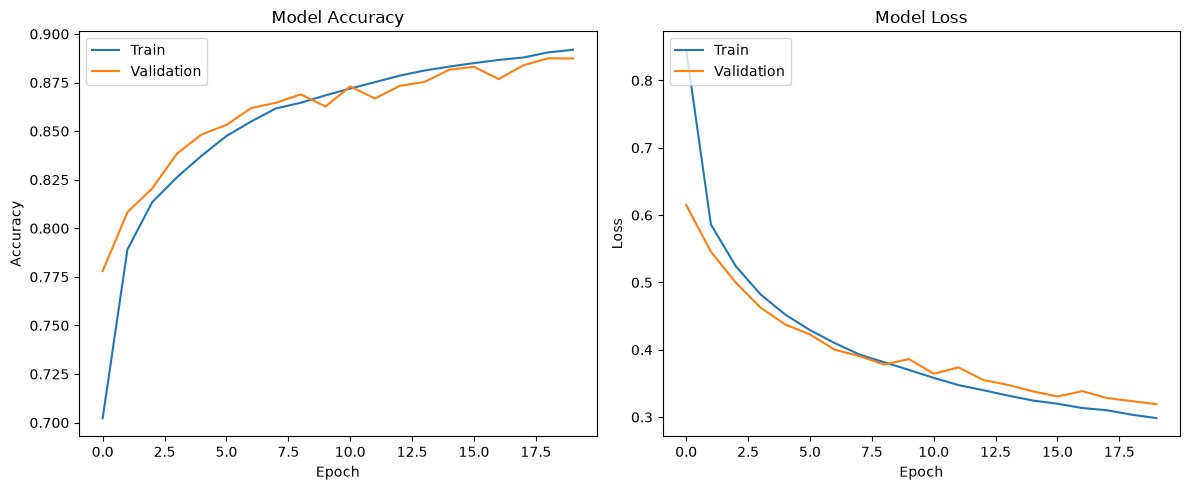

In [12]:
# โค้ดสำหรับแบบฝึก 2 ข้อที่ 1
model_with_2pool = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28,28,1)), 
    keras.layers.AveragePooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    keras.layers.AveragePooling2D((2,2)),
    keras.layers.Flatten(),
    # keras.layers.Dense(32, activation='relu'), # (ถ้าอยากลอง fine-tune โมเดล)
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_with_2pool.summary()

model_with_2pool.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
history_with_2pool = model_with_2pool.fit(train_images_zoomed, train_labels, batch_size=128, 
                                        epochs=20, validation_data=(test_images_zoomed, test_labels))

plot_history(history_with_2pool)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.2695 - loss: 1.9526 - val_accuracy: 0.4501 - val_loss: 1.5629
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.4109 - loss: 1.5309 - val_accuracy: 0.5129 - val_loss: 1.3872
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.4581 - loss: 1.4275 - val_accuracy: 0.5354 - val_loss: 1.3196
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.4859 - loss: 1.3781 - val_accuracy: 0.5854 - val_loss: 1.2761
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.5058 - loss: 1.3320 - val_accuracy: 0.6109 - val_loss: 1.2366
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.5301 - loss: 1.2993 - val_accuracy: 0.6145 - val_loss: 1.1942
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5478 - loss: 1.2639 - val_accuracy: 0.6560 - val_loss: 1.1533
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5639 - loss: 1.2308 - 

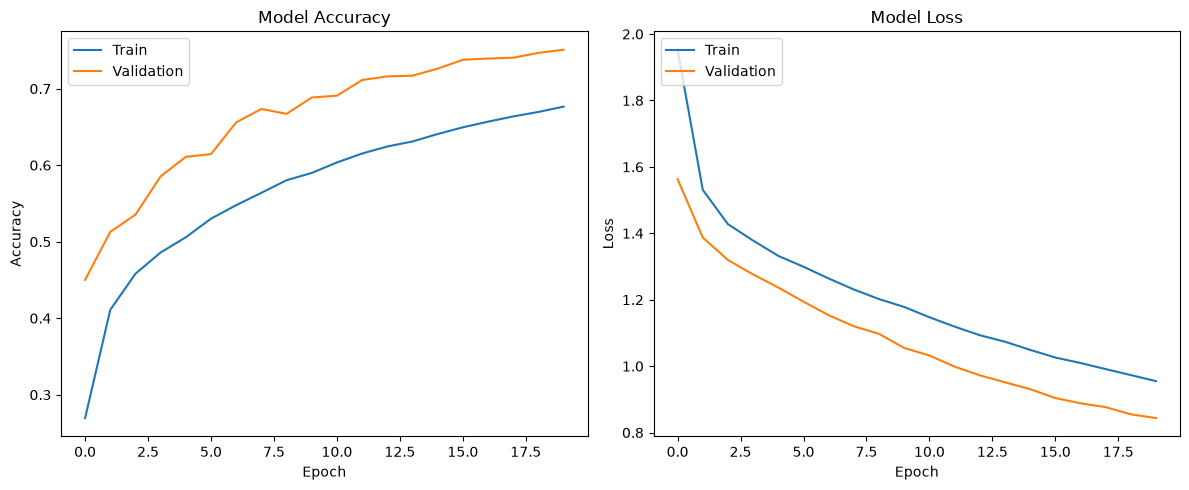

In [16]:
# โค้ดสำหรับแบบฝึก 2 ข้อที่ 2
# we have GlobalAveragePooling2D and GlobalMaxPooling2D 
model_with_2pool = tf.keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28,28,1)), 
    # keras.layers.GlobalAveragePooling2D(),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Flatten(),
    # keras.layers.Dense(32, activation='relu'), # (ถ้าอยากลอง fine-tune โมเดล)
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_with_2pool.summary()

model_with_2pool.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
history_with_2pool = model_with_2pool.fit(train_images_zoomed, train_labels, batch_size=128, 
                                        epochs=20, validation_data=(test_images_zoomed, test_labels))

plot_history(history_with_2pool)

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 4
> for the three model using different pooling layer: MaxPooling (m1), AveragePooling (m2) and GlobalPooling (m3)
> m2 is the worst of this three, maybe because this how it work inside it as the m3 took only one value from feature map which make the model lose the important pattern
> m1 and m2 is almost the same (m1 is better as shown in the value table ), for this dataset using maxpooling is the best choice because our model learn the pattern better given the value of val_acc and val_loss the best of all


## ระวังเรื่อง shape เมื่อใช้ maxpool หลายชั้น

ด้วยที่ว่าขนาดของ feature map จะลดลงทุกๆครั้งที่ผ่าน max pool ถ้าหากมีการใช้เทคนิคนี้มากจนเกินไป ขนาดของ feature map จะเล็กจนเกินไป (เล็กจนไม่สามารถทำหน้าที่เป็น feature ได้อีกต่อไป) เช่น

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,938 (1.54 MB)

 Trainable params: 404,938 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.7432 - loss: 0.6957 - val_accuracy: 0.7980 - val_loss: 0.5535
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8443 - loss: 0.4246 - val_accuracy: 0.8567 - val_loss: 0.4011
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8700 - loss: 0.3505 - val_accuracy: 0.8680 - val_loss: 0.3625
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8842 - loss: 0.3118 - val_accuracy: 0.8678 - val_loss: 0.3654
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8951 - loss: 0.2824 - val_accuracy: 0.8731 - val_loss: 0.3365
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9037 - loss: 0.2601 - val_accuracy: 0.8791 - val_loss: 0.3412
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9106 - loss: 0.2395 - val_accuracy: 0.8837 - val_loss: 0.3143
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9179 - loss: 0.2212 - 

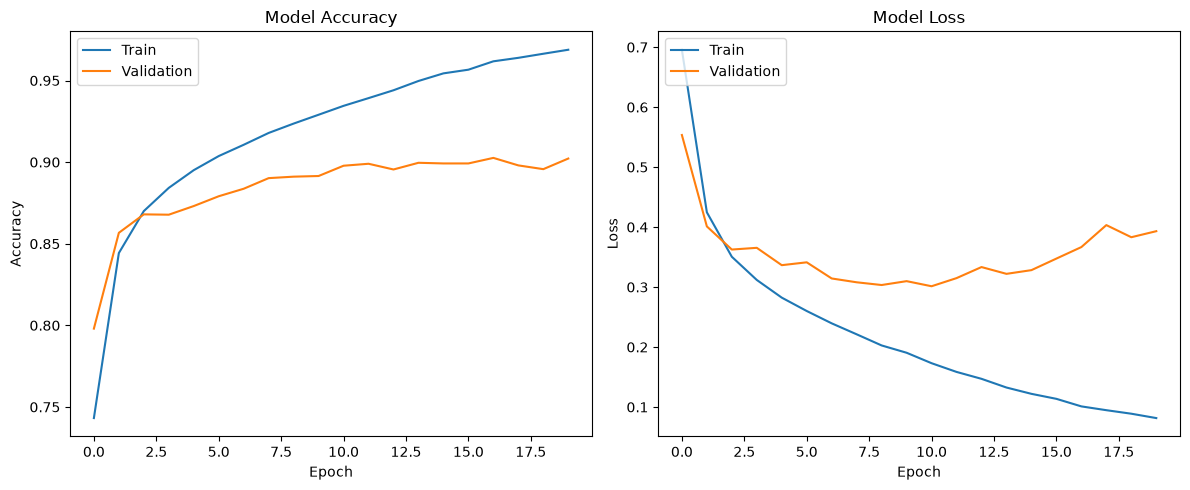

In [17]:
# CNN model ที่มี MaxPooling 4 ชั้น

model_4_maxpool = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28,28,1)), 
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_4_maxpool.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

model_4_maxpool.summary()


history_4_maxpool = model_4_maxpool.fit(train_images_zoomed, train_labels, batch_size=128, 
                                        epochs=20, validation_data=(test_images_zoomed, test_labels))

plot_history(history_4_maxpool)

การทำให้ feature map นั้นมีขนาดเหลือเพัยง 1x1 (เหลือ 1 pixelเฉยๆ) นั้นอาจจะเกิดปัญหาตามมาได้เพราะว่า
> โมเดลนั้นเสียความรู้เชิงพื้นที่ไป เพราะมีการลดขนาดมากเกิน หากความกว้างนั้นเป็นปัจจัยหนึ่งในการทำนาย โมเดลก็จะทำนายไม่ได้ทันที <br>
> ถ้าไปทำแบบนี้กับงานประเภท object detection (หาวัตถุภายในภาพ) จะเห็นผลกระทบทันที

แต่ถ้าใช้งานกับแค่ classification มันจะไม่มีปัญหาในการทำนายเลย เพราะมันก็แค่แปลง conv2 ชั้นสุดท้ายให้เป็น dense เฉยๆ ซึ่งก็เป็นกระบวนการที่ทำกันเป็นปกติอยู่แล้ว (เทียบเท่ากับ flatten นั่นแหละ) ไม่เชื่องลองไป fit() ดูได้ครับ